# OSETI Sandbox

This notebook provides library and setup support for quick tests and exploration of the HARPS optical seti analysis.

In [1]:
%matplotlib ipympl

In [2]:
from astroquery.eso import Eso
eso = Eso()
from pathlib import Path
eso_cache_folder = Path(eso.cache_location)
import harpscompare
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
import optical_seti_functions

In [3]:
from importlib import reload
reload(harpscompare)

<module 'harpscompare' from 'c:\\Users\\goodm\\OneDrive\\Documents\\optical_seti\\harpscompare.py'>

Login if needed.

In [4]:
if not eso.authenticated():
    eso.login(username="goodmanj", store_password=True)

INFO: Authenticating goodmanj on 'www.eso.org' ... [astroquery.eso.core]
INFO: Authentication successful! [astroquery.eso.core]


Lists of target stars, dates, and wavelength ranges to be analyzed.  We begin with HD127423, which was previously analyzed.

In [6]:
target_star = [
"HIP59341",
"CD-312415",
"GJ317",
"HD127423",
"HD96673",
"HIP87607",
"HIP87607",
"GJ4291"
]

target_date = [
'2013-06-01T02:04:25.906..2013-06-01T04:04:25.906', #HIP59341
'2018-02-11T00:10:40.597..2018-02-11T02:10:40.597', # CD-312415
'2018-04-10T02:25:08.275..2018-04-10T04:25:08.275', # GJ317
'2013-06-01T03:16:19.375..2013-06-01T05:16:19.375', #HD127423
'2006-01-28T06:17:55.086..2006-01-28T08:17:55.086', #HD96673
'2012-10-22T22:39:09.238..2012-10-23T00:39:09.238', #HIP87607
'2013-04-30T08:50:45.212..2013-04-30T10:50:45.212', #HIP87607
'2005-07-20T03:08:04.468..2005-07-20T06:05:04.468' # GJ4291
]

wavelim = [
[4037,4047],##HIP59341
[(3931.24-5),(3931.24+5)], #CD-312415
[4656,4672], #GJ317
[(5732.93-5),(5732.93+5)], #HD127423
[3926,3936], #HD96673
[4037,4047],  #HIP87607
[5449,5459],  #HIP87607
[3837,3846]  #GJ4291
]

which_target = 2  # Start with HD 127423

# Which comes first?

Get a table of all observations of this star, and see where the first row in the table ranks, by observation date.

In [5]:
tbl = eso.query_surveys(surveys='HARPS',target=target_star[which_target],box=0.1)
print(tbl)

          ARCFILE            Object  ... REFERENC
--------------------------- -------- ... --------
ADP.2017-02-09T01:01:25.065    GJ317 ...       --
ADP.2014-09-26T16:54:08.527    GJ317 ...       --
ADP.2024-01-29T01:01:11.192    GJ317 ...       --
ADP.2024-04-29T01:00:37.298    GJ317 ...       --
ADP.2024-01-01T01:00:53.675    GJ317 ...       --
ADP.2024-03-27T01:01:12.345    GJ317 ...       --
ADP.2014-10-07T08:34:19.500   GJ-317 ...       --
ADP.2024-04-05T01:01:37.447    GJ317 ...       --
ADP.2017-11-25T01:01:42.832    GJ317 ...       --
ADP.2024-03-10T01:01:18.257    GJ317 ...       --
                        ...      ... ...      ...
ADP.2018-01-08T01:02:26.785    GJ317 ...       --
ADP.2017-12-05T01:01:38.972    GJ317 ...       --
ADP.2014-10-06T10:06:18.577   GJ-317 ...       --
ADP.2014-10-06T10:05:53.233   GJ-317 ...       --
ADP.2014-10-06T10:07:07.860   GJ-317 ...       --
ADP.2014-09-26T16:54:01.513 L 675-81 ...       --
ADP.2014-10-07T08:34:42.203   GJ-317 ...       --


In [7]:
for which_target in range(len(target_star)):
    tbl = eso.query_surveys(surveys='HARPS',target=target_star[which_target],box=0.1,cache=False)
    print(np.count_nonzero(tbl['Date Obs'] > tbl['Date Obs'][0])/len(tbl))

KeyboardInterrupt: 

In [ ]:
for which_target in range(len(target_star)):
    tbl = eso.query_surveys(surveys='HARPS',target=target_star[which_target],box=0.1,cache=True)
    print(np.count_nonzero(tbl['SNR'] > tbl['SNR'][0])/len(tbl))

0.6666666666666666
0.6
0.04
0.625
0.0
0.3888888888888889
0.3888888888888889
0.62


# Monte-Carlo test of sensitivity to noise

Is our automated search algorithm sensitive to random noise?  Begin by loading one of our observations:

In [ ]:
arcfile = "ADP.2018-04-11T01:01:47.531"
cached_file = eso_cache_folder /  (arcfile.replace(":","_")+".fits")
f = fits.open(cached_file)
wave = f[1].data[0][0] 
arr1 = f[1].data[0][1]


C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2018-04-11T01_01_47.531.fits


Calculate the lag-1 autocorrelation of this spectrum.

In [10]:
y = arr1[500:-500] - optical_seti_functions.running_median(arr1,1001)
cc = np.corrcoef(y[0:-1],y[1:])
print(cc[1][0])

0.8487622458601595


Create a synthetic null dataset: Gaussian random noise, filtered through a moving-average filter.  The filter width (6) is selected so the synthetic dataset has the same lag-1 autocorrelation as the real HARPS data.

In [11]:
ysyn = optical_seti_functions.running_mean(np.random.randn(len(arr1)),6)+5

In [12]:
cc = np.corrcoef(ysyn[0:-1],ysyn[1:])
print(cc)

[[1.         0.83316047]
 [0.83316047 1.        ]]


Create 1000 such synthetic datasets, and search for SETI spikes in them.

In [ ]:
hit_count = []
for i in range(1000):
    ysyn = optical_seti_functions.running_mean(np.random.randn(len(arr1)),6)+5
    hits_start, hits_end, count = optical_seti_functions.seti_spike_analyzer(ysyn, min_count = 4, max_count = 500, threshold_multiplier = 7.5, window_size = 1001,percentile=85)
    print("%d: %d"%(i,len(hits_start)))
    hit_count.append(len(hits_start))
print(hit_count)

Count the hits: zero.

In [19]:
sum(hit_count)

0

# Compare repeater spectra

Show repeater spectra with similar wavelengths on the same graph.

C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-26T16_53_42.797
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-26T16_53_42.797 to be downloaded
INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 1 files ... [astroquery.eso.core]
INFO: Downloading file 1/1 https://dataportal.eso.org/dataPortal/file/ADP.2014-09-26T16:53:42.797 to C:\Users\goodm\.astropy\cache\astroquery\Eso [astroquery.eso.core]
INFO: Found cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-26T16_53_42.797.fits [astroquery.eso.core]
INFO: Done! [astroquery.eso.core]
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-25T15_35_18.127
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-25T15_35_18.127 to be downloaded
INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 1 files ... [astroquery.eso.core]
INFO: Downloading file 1/1 https://dataportal.eso.org/dataPortal/file/ADP.2014-09-25T15:35:18.127 to C:\Users\goodm\.astropy\cache\astroqu

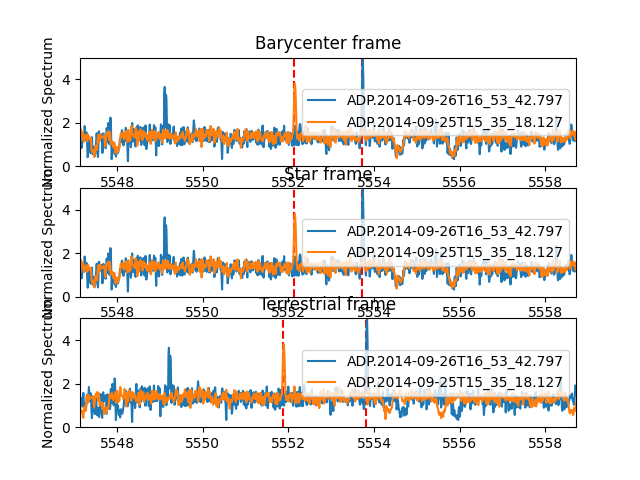

Relative velocity: 42.921703 km/s


In [5]:
def cached_filename(file): 
    file_no_colon = str(file).replace(":","_") 
    return eso_cache_folder/(file_no_colon)

def download_if_needed(file):
    fits_specfile_name = cached_filename(file)   # underscore version, used for exists() check
    print(fits_specfile_name)
    if not fits_specfile_name.exists():
        print(str(fits_specfile_name) + " to be downloaded")
        result = eso.retrieve_data(file)
        # retrieve_data returns the actual saved path (with colons) — use that instead
        actual_path = Path(result[0]) if isinstance(result, list) else Path(result)
        return actual_path
    else:
        print(str(fits_specfile_name) + " exists")
        return fits_specfile_name


def compare_spectra_doppler(specfiles,lambs):
    lambs = np.array(lambs)
    specfits = [fits.open(f) for f in specfiles]
    radvels = [f[0].header["HIERARCH ESO TEL TARG RADVEL"] for f in specfits]
    radvels = [max(v,0) for v in radvels]
    berv    = [f[0].header["HIERARCH ESO DRS BERV"] for f in specfits]         # Observatory's velocity in barycentric frame

    wave = [f[1].data[0][0] for f in specfits]
    arr1 = [f[1].data[0][1] for f in specfits]

    wave_starframe = [harpscompare.doppler(wave[i],radvels[i]) for i in range(len(radvels))]
    wave_obsframe = [harpscompare.doppler(wave[i],berv[i]) for i in range(len(radvels))]

    lambs_starframe = [harpscompare.doppler(lambs[i],radvels[i]) for i in range(len(lambs))]
    lambs_obsframe = [harpscompare.doppler(lambs[i],berv[i]) for i in range(len(lambs))]

    norm_spec = [s/np.median(s) for s in arr1]
    wavelim = [min(lambs)-5,max(lambs)+5]

    plt.clf()
    plt.subplot(3,1,1)
    plt.plot([lambs,lambs],[0*lambs,0*lambs+5],'r--')
    for i in range(len(specfits)): 
        plt.plot(wave[i],norm_spec[i],label=specfiles[i].stem)
    plt.xlim(wavelim) 
    plt.ylim([0,5]) 
    plt.legend(loc='right') 
    plt.title("Barycenter frame") 
    plt.ylabel("Normalized Spectrum") 
    plt.subplot(3,1,2)
    plt.plot([lambs_starframe,lambs_starframe],[0*lambs,0*lambs+5],'r--')
    for i in range(len(specfits)): 
        plt.plot(wave_starframe[i],norm_spec[i],label=specfiles[i].stem) 
    plt.xlim(wavelim) 
    plt.ylim([0,5]) 
    plt.legend(loc='right') 
    plt.title("Star frame") 
    plt.ylabel("Normalized Spectrum") 
    plt.subplot(3,1,3)
    plt.plot([lambs_obsframe,lambs_obsframe],[0*lambs,0*lambs+5],'r--')
    for i in range(len(specfits)): 
        plt.plot(wave_obsframe[i],norm_spec[i],label=specfiles[i].stem) 
    plt.xlim(wavelim) 
    plt.ylim([0,5]) 
    plt.legend(loc='right') 
    plt.title("Terrestrial frame") 
    plt.ylabel("Normalized Spectrum") 
    plt.show()

specfiles = ["ADP.2014-09-26T16:53:42.797","ADP.2014-09-25T15:35:18.127"]
specfiles = [eso_cache_folder/file for file in specfiles] 
specfiles = [download_if_needed(file.name) for file in specfiles]
lambs = [5553.72,5552.13]
compare_spectra_doppler(specfiles,lambs)
v = (lambs[0]-lambs[1])/(lambs[0]+lambs[1])*2.998e5 # km/s
print("Relative velocity: %f km/s"%(v))

In [80]:
print("%f, %f"%(max(wave),min(wave)))

6912.360000, 3781.620000


In [33]:
#specfile = cached_filename("ADP.2014-09-26T16:53:42.797.fits")
#lamb = 5553.72
#f = "ADP.2014-09-25T15:35:09.757"
#specfile = cached_filename(f+".fits")
#lamb = 6781.13
#f = "ADP.2014-10-06T10:07:06.050"
#lamb=4360.92
f="ADP.2014-10-02T10:01:25.993"
lamb= 6093.55
specfile = cached_filename(f+".fits")
#specfile = cached_filename("ADP.2014-09-25T15:35:18.127.fits")
#lamb = 5552.13
f = download_if_needed(f)
ccdfile = harpscompare.download_associated_raw(specfile)

C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_01_25.993
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_01_25.993 to be downloaded
INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 1 files ... [astroquery.eso.core]
INFO: Downloading file 1/1 https://dataportal.eso.org/dataPortal/file/ADP.2014-10-02T10:01:25.993 to C:\Users\goodm\.astropy\cache\astroquery\Eso [astroquery.eso.core]
INFO: Found cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_01_25.993.fits [astroquery.eso.core]
INFO: Done! [astroquery.eso.core]
INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 1 files ... [astroquery.eso.core]
INFO: Downloading file 1/1 https://dataportal.eso.org/dataPortal/file/HARPS.2005-05-10T04:34:42.474 to C:\Users\goodm\.astropy\cache\astroquery\Eso [astroquery.eso.core]
INFO: Successfully downloaded dataset HARPS.2005-05-10T04:34:42.474 to C:\Users\goodm\.astropy\cache\astroquery\Eso\HARPS.2005-05-1

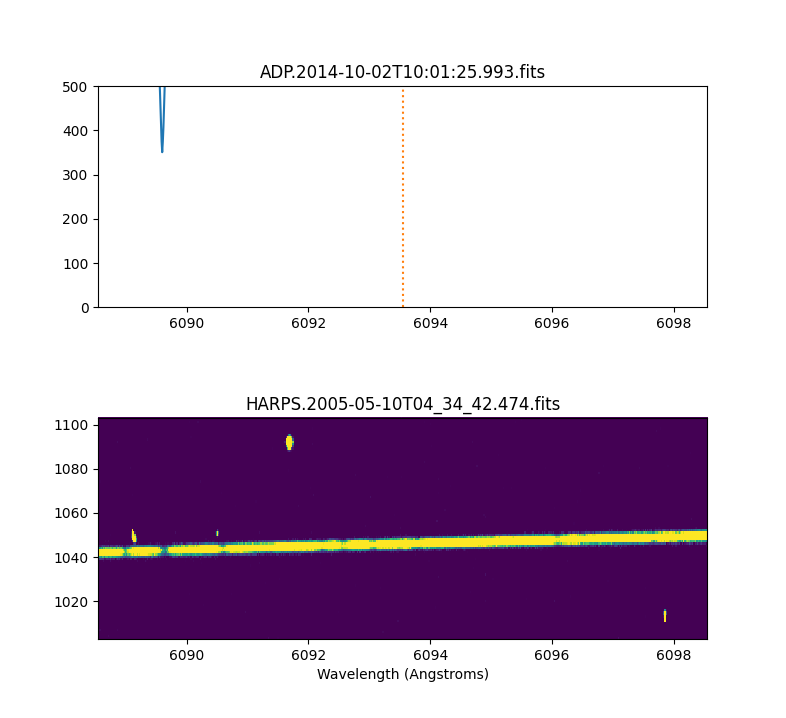

In [ ]:
plt.figure(2)
plt.clf()
harpscompare.compare_spec_to_raw(specfile,ccdfile,lamb/10,multi_order=True,lamb_range=[lamb/10-.5,lamb/10+.5],
                                 doppler_shift=True)

In [5]:
airglow_database = fits.open("hanuschik-full.fits")  # Merge Table 5 and 6 from Hanuschik
airglow_data = [airglow_database[i] for i in range(1,len(airglow_database))]
airglow_lambda = np.concatenate([airglow_data[i].data['lambda'] for i in range(len(airglow_data))])
airglow_fwhm = np.concatenate([airglow_data[i].data['fwhm'] for i in range(len(airglow_data))])

In [6]:
import matplotlib.patches as patches
def myboxplot(ax,x,y,width,height,color='r'):
    ax.plot([x,x],[y,y+height],color)
    ax.add_patch(patches.Rectangle((x-width/2,y+height/4),width,height/2,edgecolor=color,facecolor='none'))

In [7]:
print(sum(airglow_fwhm))

312.0712999999998


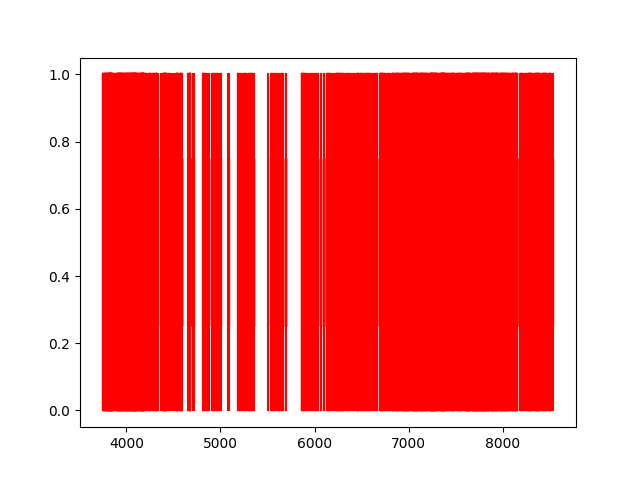

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

...

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

In [8]:
plt.figure(3)
plt.clf()
for alamb,afwhm in zip(airglow_lambda,airglow_fwhm):
    # Plot them using myboxplot, defined above
    myboxplot(plt.gca(),alamb,0,afwhm,1)
plt.show()